In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Загрузка и очистка данных

In [23]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df = df.drop("customerID", axis=1)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

class_counts = df["Churn"].value_counts(normalize=True) * 100
print(f"Баланс классов:\nНе ушли - {class_counts[0]:.1f}%\nУшли - {class_counts[1]:.1f}%")
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(df.columns)

Баланс классов:
Не ушли - 73.5%
Ушли - 26.5%
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


Данные загружены и почищены. Лишний столбец удален, ошибки в цифрах исправлены, а целевую переменную перевели в 0 и 1. Данные разделили на обучающую и тестовую части.

# Пайплайн предобработки

In [7]:
numeric_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]
# Ветка 1: Обработка чисел
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)
# Ветка 2: Обработка категорий (текста)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)
# 1 + 2
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
# Итоговый конвейер: Предобработка -> Модель
clf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier())
    ]
)
param_grid = {
    "classifier__n_neighbors": [3, 5, 9],
    "classifier__weights": ["uniform", "distance"]
}
# 5-fold кросс-валидация
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=clf_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print(f"Лучшие параметры алгоритма: {grid_search.best_params_}")

Лучшие параметры алгоритма: {'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}


Вся подготовка данных и модель KNN были собраны в один конвейер. С помощью перебора параметров (GridSearch) программа нашла самые лучшие настройки для модели и вывела их.

# Оценка качества классификации

In [8]:
# предскажем 0 или 1
y_pred = best_model.predict(X_test)
# Предсказание вероятностей от 0.0 до 1.0 (для ROC-AUC)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("--- Матрица ошибок ---")
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Истинно отрицательные (TN - клиент не ушёл, предсказали верно) {conf_matrix[0][0]}")
print(f"Ложноположительные (FP - клиент не ушёл, предсказали уход) {conf_matrix[0][1]}")
print(f"Ложноотрицательные (FN - клиент ушёл, предсказали что остался) {conf_matrix[1][0]}")
print(f"Истинно положительные (TP - клиент ушёл, предсказали верно) {conf_matrix[1][1]}")

print("--- Отчет по метрикам ---")
print(classification_report(y_test, y_pred, target_names=["Не ушёл (0)", "Ушёл (1)"]))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"Площадь под кривой ROC-AUC: {roc_auc:.4f}")

--- Матрица ошибок ---
Истинно отрицательные (TN - клиент не ушёл, предсказали верно) 880
Ложноположительные (FP - клиент не ушёл, предсказали уход) 155
Ложноотрицательные (FN - клиент ушёл, предсказали что остался) 155
Истинно положительные (TP - клиент ушёл, предсказали верно) 219
--- Отчет по метрикам ---
              precision    recall  f1-score   support

 Не ушёл (0)       0.85      0.85      0.85      1035
    Ушёл (1)       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

Площадь под кривой ROC-AUC: 0.8134


Модель показала хорошую общую точность (точность 78%, ROC-AUC 0.81), но она гораздо лучше предсказывает тех, кто остается (85%), чем тех, кто уходит (всего 59%).
155 ложноположительных, где клиент не ушёл, но предсказали уход не является убытком, а 155 ложноотрицательных,когда клиент ушёл, а предсказали что остался является прямая потеря клиентов и выручки

In [13]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Регрессия

In [27]:
df_reg = df.dropna(subset=['TotalCharges']).copy()
X_reg = df_reg[["SeniorCitizen", "tenure"]]
y_reg = df_reg["TotalCharges"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_pipeline = Pipeline(
    [("scaler", StandardScaler()), ("knn_reg", KNeighborsRegressor())]
)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_dist = {
    "knn_reg__n_neighbors": np.arange(3, 30),
    "knn_reg__weights": ["uniform", "distance"]
}
random_search = RandomizedSearchCV(
    estimator=reg_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=kf,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_r, y_train_r)
best_reg = random_search.best_estimator_
print(f"Лучшие параметры алгоритма: {random_search.best_params_}")

Лучшие параметры алгоритма: {'knn_reg__weights': 'uniform', 'knn_reg__n_neighbors': np.int64(29)}


Мы обучили модель предсказывать общую сумму расходов (TotalCharges) на основе того, является ли клиент пожилым, и как долго он пользуется услугами. Программа перебрала настройки и нашла лучшие: 29 соседей и равный вес.

# Метрики регрессии

In [25]:
y_pred_r = best_reg.predict(X_test_r)
def smape(y_test, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_test) / (np.abs(y_test) + np.abs(y_pred))
    )
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_r, y_pred_r)
smape_value = smape(y_test_r, y_pred_r)

print("--- Отчет по метрикам регрессии ---")
print(f"MSE (квадратные $): {mse:.0f}")
print(f"RMSE ($): {rmse:.0f}")
print(f"MAE (Средняя ошибка, $): {mae:.2f}")
print(f"SMAPE (ошибка в %): {smape_value:.2f}%")

--- Отчет по метрикам регрессии ---
MSE (квадратные $): 1702537
RMSE ($): 1305
MAE (Средняя ошибка, $): 848.12
SMAPE (ошибка в %): 43.80%


Модель посчитала ошибки: в среднем она промахивается на 848 долларов, а процентная ошибка составляет почти 44%. Это довольно низкая точность.

# Визуализация результатов

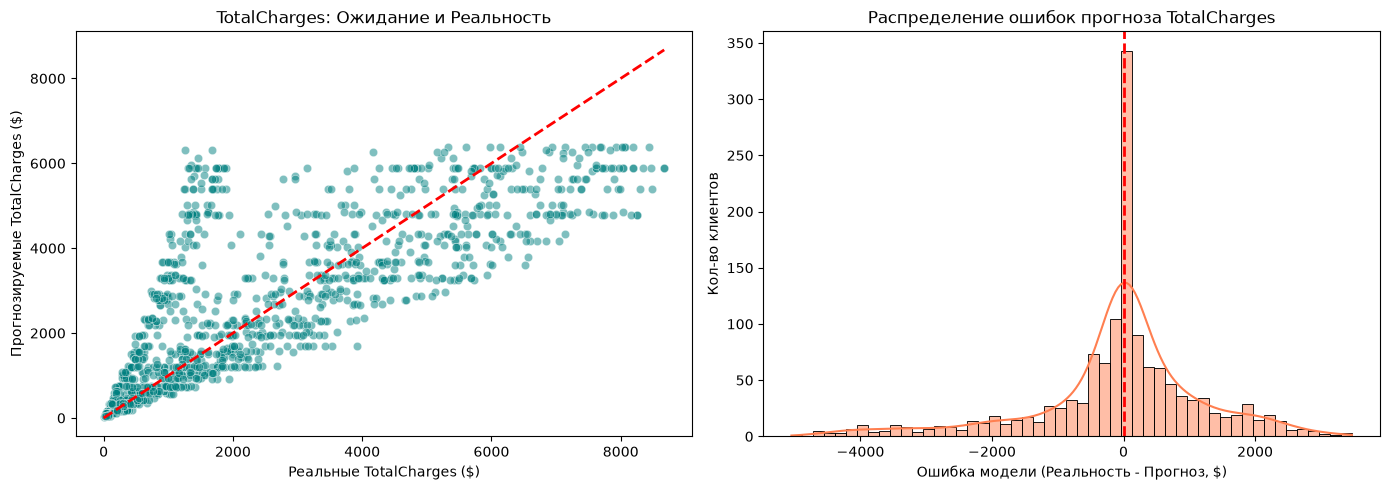

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1 график: Факт vs Прогноз
sns.scatterplot(x=y_test_r, y=y_pred_r, alpha=0.5, color="teal", ax=axes[0])
y_min = min(y_test_r.min(), y_pred_r.min())
y_max = max(y_test_r.max(), y_pred_r.max())
axes[0].plot([y_min, y_max], [y_min, y_max], 'r--', lw=2)
axes[0].set_title("TotalCharges: Ожидание и Реальность")
axes[0].set_xlabel("Реальные TotalCharges ($)")
axes[0].set_ylabel("Прогнозируемые TotalCharges ($)")

# 2 график: Распределение ошибок
residuals = y_test_r - y_pred_r
sns.histplot(residuals, kde=True, color='coral', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_title("Распределение ошибок прогноза TotalCharges")
axes[1].set_xlabel("Ошибка модели (Реальность - Прогноз, $)")
axes[1].set_ylabel("Кол-во клиентов")

plt.tight_layout()
plt.show()

Визуализация подтверждает низкое качество модели. График рассеяния показывает сильный разброс точек относительно прогноза. Гистограмма остатков имеет широкий размах, что говорит о больших ошибках. Модель требует доработки.

Вывод: Была построена модель, чтобы предсказывать траты клиентов, используя только два признака (пожилой ли клиент и сколько месяцев он с нами). Таким образом, модель работает плохо. Ошибка почти 44%. Графики это подтверждают, что прогнозы сильно не совпадают с реальностью. Таким образом, можно сказать, что на основе выбраных факторов нельзя сделать корректное предсказание. 
